# Self exploration

In [2]:
#!pip install category_encoders 

In [18]:
#!pip install statsmodels numpy pandas matplotlib seaborn
# Importing the required libraries
import matplotlib.pyplot as plt
import numpy as np

#ignore pandas warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd
import seaborn as sns
import os
import category_encoders as ce

DATA_FILEPATH = r"../../A_data/climate_clean_encoded.csv"
GRAPH_FILEPATH = "./graphs/"

dataset = pd.read_csv(DATA_FILEPATH)
data_size = dataset.shape
print(f"The Dataset has a size of {data_size[0]} rows and {data_size[1]} columns/features, containing {data_size[0]*data_size[1]} entries.")

The Dataset has a size of 302 rows and 15 columns/features, containing 4530 entries.


### Helpful Functions

In [4]:
def store_graph_in_subfolder(subfolder="", root = True):
    """
    Function to create a folder for storing graphs.
    
    Parameters:
        :param subfolder: The name of the subfolder to store the graphs. If blank, it will use the default path.
        :param root: If True, it will reset the graph file path to 'current_working_folder/graphs/'.
    """
    global GRAPH_FILEPATH
    if root:
        GRAPH_FILEPATH = "./graphs/"
    
    if subfolder != "":
        if subfolder[0] == "/":
            subfolder = subfolder[1:]
        if subfolder[-1] != "/":
            subfolder = subfolder + "/"
    
    GRAPH_FILEPATH += subfolder
    
    os.makedirs(GRAPH_FILEPATH,exist_ok = True)
    
    if os.path.isdir(GRAPH_FILEPATH):
        return GRAPH_FILEPATH
    else:
        raise NameError("Failed to update the graph folder path.")

In [5]:
def plot_relevant_visualisations(column_name, df, modifier = '', kind='line', log=False, indiv_folder_name = GRAPH_FILEPATH+'individual_visualisations/'):
    """
    Generate and save visualizations for a specific column in the dataframe.
    
    Parameters:
    ----------
        column_name : str
            Name of the column to visualize.
        df : pandas.DataFrame
            DataFrame containing the data.
        modifier : str, optional
            String to append to the output filename. Default is empty string.
        kind : str, optional
            Type of plot for time series visualization. Options: 'line' or 'scatter'. Default is 'line'.
        log : bool, optional
            If True, includes an additional histogram of log-transformed values. Default is False.
        indiv_folder_name : str, optional
            Directory path to save visualizations. Default is GRAPH_FILEPATH+'individual_visualisations/'.
    
    Returns:
    -------
        bool
            True if the visualization was successfully saved, False otherwise.
    
    Notes:
    ------
        Creates up to three visualizations:
        1. Histogram showing the distribution with bin frequencies
        2. Time series plot showing values over time
        3. If log=True, histogram of log-transformed values with calculated skewness
        
        The function requires a 'continuous_months' column in the dataframe, which will be 
        created if it doesn't exist based on Year and Month columns.
    """

    # Create continuous_months column if it doesn't exist
    if 'continuous_months' not in df.columns:
        # Calculate continuous months from Year and Month columns
        df['continuous_months'] = (df['Year'] - df['Year'].min()) * 12 + df['Month']
    
    # Create directory if it doesn't exist
    os.makedirs(indiv_folder_name, exist_ok=True)
    
    #log affects the number of plots, and associated variables.
    num_plots = 2 if not log else 3
    SCALE_FACTOR = 5
    fig, axes = plt.subplots(1, num_plots, figsize=((SCALE_FACTOR+1)*num_plots, SCALE_FACTOR))
    
    if not log:
        ax_hist, ax_line = axes
    else:
        ax_hist, ax_line, ax_log = axes
    
    freq, bins, patches = ax_hist.hist(df[column_name], bins=20, edgecolor='white')
    
    bin_centers = np.diff(bins)*0.5 + bins[:-1]

    n = 0
    for fr, x, patch in zip(freq, bin_centers, patches):
        height = int(freq[n])
        ax_hist.annotate("{}".format(height),
                    xy = (x, height),
                    xytext = (0,0.2),
                    textcoords = "offset points",
                    ha = 'center', va = 'bottom'
                    )
        n = n+1
    
    ax_hist.set_title(f"Distribution of {column_name} \n (with labelled frequencies)", fontsize=10)
    ax_hist.set_xlabel(column_name, fontsize=10)
    ax_hist.set_ylabel("Frequency", fontsize=10)
    
    if kind == 'line':
        ax_line.plot(df['continuous_months'],df[column_name],color='orange')
    else:
        ax_line.scatter(df['continuous_months'],df[column_name],color='orange')
    
    ax_line.set_title(f"{column_name} levels over time", fontsize=12)
    ax_line.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: str(int(x//12))))
    ax_line.set_xlabel('Year', fontsize=10)
    ax_line.set_ylabel(column_name, fontsize=10)
    
    if log:
        logdf = df[column_name].copy().apply(np.log)
        new_skew = logdf.skew()
        
        lfreq, lbins, lpatches = ax_log.hist(logdf,bins=20,edgecolor='white',color='green')
        
        lbin_centers = np.diff(lbins)*0.5 + lbins[:-1]

        n = 0
        for fr, lx, patch in zip(lfreq, lbin_centers, lpatches):
            lheight = int(lfreq[n])
            ax_log.annotate("{}".format(lheight),
                        xy = (lx, lheight),             # top left corner of the histogram bar
                        xytext = (0,0.2),             # offsetting label position above its bar
                        textcoords = "offset points", # Offset (in points) from the *xy* value
                        ha = 'center', va = 'bottom'
                        )
            n = n+1
        
        ax_log.set_title(f"Distribution after log_transformation \n of {column_name} (new skew: {new_skew:.2f})", fontsize=10)
        ax_log.set_xlabel(column_name, fontsize=10)
        ax_log.set_ylabel("Frequency", fontsize=10)
    
    plt.savefig(indiv_folder_name + f"{column_name}{modifier}_visualisations.png")
    plt.show()
    
    return os.path.isfile(indiv_folder_name + f"{column_name}{modifier}_visualisations.png")

In [6]:
def plot_scatter(col, dataset_clean_encoded):
    """
    Generate scatter plots of a specified column against all numeric (float64) variables in the dataset,
    excluding certain columns.
    
    Parameters:
    ----------
    col : str
        The name of the column to use as the x-axis in all scatter plots.
    dataset_clean_encoded : pandas.DataFrame
        The DataFrame containing the data to visualize.
        
    Returns:
    -------
    None
        The function saves the generated figure and displays it using plt.show().
    
    Notes:
    ------
    - Creates a single figure with multiple subplots - one for each eligible continuous variable
    - Excludes 'Month' from the plottable columns
    - Saves the figure in a subdirectory structure: {folder_name}/{col}/overall/
    - The figure filename follows the pattern: 3c_{col}_scatterplot_base.png
    - Requires matplotlib.pyplot as plt and os to be imported
    - The variable 'folder_name' should be defined before calling this function
    """

    #CHANGE HERE
    excluded_cols = {'Month'}
    SCALE_FACTOR = 9
    cols = list(dataset_clean_encoded.select_dtypes(include=['float64']))
    
    plottable_columns = list(set(cols) - excluded_cols)
    #print(plottable_columns)
    fig, axes = plt.subplots(1,len(plottable_columns),figsize = (len(plottable_columns) * int(SCALE_FACTOR*1.2),SCALE_FACTOR))

    for cont_var in range(len(plottable_columns)):
        column_name = plottable_columns[cont_var]
        if column_name not in excluded_cols:
            sample_axes = axes[cont_var]
            
            sample_axes.scatter(dataset_clean_encoded[col],\
                                dataset_clean_encoded[column_name])
            
            sample_axes.set_title(f"{col} against {column_name} ")
            sample_axes.set_xlabel(col)
            sample_axes.set_ylabel(column_name)

    plt.suptitle(f"Scatter plot of {col} against all continuous variables")
    
    subfolder_name = folder_name + f'{col}/overall/'
    os.makedirs(subfolder_name, exist_ok=True)    
    plt.savefig(subfolder_name+f"3c_{col}_scatterplot_base.png")
    plt.show()

In [7]:
def plot_with_color_separation(col,dataset_clean_encoded):
    """
    Generate scatter plots of a specified column against all continuous variables,
    with points colored by categorical variables in the dataset.
    
    Parameters:
    ----------
    col : str
        The name of the column to use as the x-axis in all scatter plots.
    dataset_clean_encoded : pandas.DataFrame
        The DataFrame containing the data to visualize.
        
    Returns:
    -------
    None
        The function saves the generated figure and displays it using plt.show().
    
    Notes:
    ------
    - Creates a grid of subplots - one row for each categorical variable and 
      one column for each continuous variable
    - Points in each scatter plot are colored according to the values of the categorical variable
    - The function uses several global variables that should be defined before calling:
      * continuous_variables: list of continuous variable names to plot
      * excluded_cols: set of column names to exclude from plotting
      * folder_name: base directory to save the plots
    - The plots are saved in a subdirectory structure: {folder_name}/{col}/overall/
    - The figure filename follows the pattern: 3c_{col}_scatterplot_categorical.png
    """
    
    SCALE_FACTOR = 9
    categorical_columns = dataset_clean_encoded.select_dtypes(include=['object', 'category']).columns
    cat_dict = {i:list(dataset_clean_encoded[i].unique()) for i in categorical_columns}

    plottable_columns = continuous_variables.copy()

    fig, axes = plt.subplots(len(cat_dict.keys()),
                            len(plottable_columns),
                            figsize = ((len(plottable_columns) * SCALE_FACTOR),
                                        (len(cat_dict.keys()) * SCALE_FACTOR)))

    cat_num = 0
    for cat_name in cat_dict.keys():
        cat_vals = cat_dict[cat_name]
        
        for cont_var in range(len(plottable_columns)):
            column_name = plottable_columns[cont_var]
            if column_name not in excluded_cols:
                sample_axes = axes[cat_num,cont_var]
                
                for cat in cat_vals:
                    sample_axes.scatter(dataset_clean_encoded[dataset_clean_encoded[cat_name]==cat][col],\
                                        dataset_clean_encoded[dataset_clean_encoded[cat_name]==cat][column_name])
                    sample_axes.set_xlabel(col)
                    sample_axes.set_ylabel(column_name)
                    sample_axes.set_title(f"{column_name} against {col}, grouping by {cat_name}")
                    sample_axes.legend(cat_vals)
        cat_num += 1

    plt.suptitle(f"{col} scatter plots, grouped by all categorical variables")

    subfolder_name = folder_name + f'{col}/overall/'
    os.makedirs(subfolder_name, exist_ok=True)      
    plt.savefig(subfolder_name+f"3c_{col}_scatterplot_categorical.png")
    
    plt.show()

In [8]:
def plot_on_1_category(cat,val,col,dataset_clean_encoded,color='blue'):
    """
    Generate scatter plots of a specified column against all continuous variables for a specific category value.
    
    Parameters:
    ----------
        cat : str
            The categorical column name used for filtering the dataset.
        val : str or any
            The value of the categorical column to filter by.
        col : str
            The column name to use as the x-axis in all scatter plots.
        color : str, optional
            The color to use for the scatter plot points. Default is 'blue'.
        
    Returns:
    -------
        None
            The function saves the generated figure and displays it using plt.show().
        
    Notes:
    ------
        - Creates multiple scatter plots - one for each continuous variable in the dataset
        - Filters the dataset to only include rows where cat=val
        - Requires several global variables to be defined before calling:
        * dataset_clean_encoded: pandas DataFrame containing the data
        * continuous_variables: list of continuous variable names to plot
        * excluded_cols: set of column names to exclude from plotting
        * folder_name: base directory to save the plots
        - Saves the figure in a subdirectory structure: {folder_name}/{col}/overall/
        - The figure filename follows the pattern: 3c_{col}_scatterplot_{cat[0]}_{val}.png
    """
    continuous_variables = dataset_clean_encoded.select_dtypes(include=['float64']).columns
    #excluded_cols = {'Month','Year'}
    dataset_used = dataset_clean_encoded[dataset_clean_encoded[cat]==val]
    
    SCALE_FACTOR = 7
    plottable_columns = continuous_variables.copy()
    
    fig, axes = plt.subplots(1,len(plottable_columns),figsize = (len(plottable_columns) * int(SCALE_FACTOR*1.3),SCALE_FACTOR))

    for cont_var in range(len(plottable_columns)):
        column_name = plottable_columns[cont_var]
        sample_axes = axes[cont_var]
            
        sample_axes.scatter(dataset_used[col],\
                                dataset_used[column_name],
                                color=color)
            
        sample_axes.set_title(f"{col} against {column_name} ")
        sample_axes.set_xlabel(col)
        sample_axes.set_ylabel(column_name)

    plt.suptitle(f"Scatter plot of {col} against all continuous variables when {cat} = {val}")
    
    subfolder_name = store_graph_in_subfolder(f'individual_visualisations/{col}/overall/')
    plt.savefig(subfolder_name+f"3c_{col}_scatterplot_{cat[0]}_{val}.png")
    plt.show()

# test plots
#plot_on_1_category('Aerosols','H','CO2',color='blue')

In [ ]:
# see boxplot function
def boxplot_across_category(col,dataset):
    """
    Generate box plots of a specified column across all unique values of a categorical variable.
    
    Parameters:
    ----------
        col : str
            The name of the column to use for the box plot.
        dataset : pandas.DataFrame
            The DataFrame containing the data to visualize.
        
    Returns:
    -------
        None
            The function saves the generated figure and displays it using plt.show().
        
    Notes:
    ------
        - Creates a single figure with multiple subplots - one for each unique value in the categorical variable
        - Each subplot shows a box plot of the specified column for that category value
        - Requires several global variables to be defined before calling:
        * dataset: pandas DataFrame containing the data
        * folder_name: base directory to save the plots
        - Saves the figure in a subdirectory structure: {folder_name}/{col}/overall/
        - The figure filename follows the pattern: 3c_{col}_boxplot.png
    """
    SCALE_FACTOR = 11
    categories = dataset[col].value_counts().index
    plottable_columns = list(dataset.select_dtypes(exclude=['object', 'category']).columns)
    plottable_columns = list(set(plottable_columns)-{
        'Aerosols_ord',
        'N2O_ord',
        'TSI_ord'
    })
    
    fig, axes = plt.subplots(1,len(plottable_columns),figsize = (len(plottable_columns) * SCALE_FACTOR*1.1, SCALE_FACTOR))
    
    cat_num = 0
    for cont_num in range(len(plottable_columns)):
        cont_col = plottable_columns[cont_num]
        sample_axes = axes[cont_num]
        for cat_val in categories:
            dataset[[col,cont_col]].boxplot(by=col,ax=sample_axes)
        
        sample_axes.set_title(f"{col} against {cont_col}")
        sample_axes.set_xlabel(col)
        sample_axes.set_ylabel(cont_col)
        
        cat_num += 1
    
    plt.suptitle(f"Box plot of {col} against all categorical variables")
    
    subfolder_name = store_graph_in_subfolder(f'boxplots/')   
    plt.savefig(subfolder_name+f"{col}_boxplot.png")
    
    plt.show()

### Feature Exploration

we will determine the candidate Variables for modelling using their weight of evidence (WOE) and Information Value (IV) to rank and filter for the categorical variables that are worthwhile modelling.  
  
Links:  
 [WOE and IV](https://www.listendata.com/2015/03/weight-of-evidence-woe-and-information.html) 
 |
 [WOE and IV Implementation with category_encoders](https://www.aionlinecourse.com/blog/how-to-get-the-weight-of-evidence-woe-and-information-value-iv-in-pythonpandas)
 |
 

In [ ]:
# rank features by percentage of their values with the modal frequency
datatypes = dataset.dtypes
categorical_features = datatypes[datatypes=="object"].index

categorical_important = []

for feature in categorical_features:
    highest = dataset[feature].value_counts(normalize=True)[0]
    categorical_important.append((feature,float(highest)))

print(f"Categorical Variables with mode contributing <50% are :\n{'\n'.join('\t'.join(str(j) for j in i[::-1]) for i in categorical_important)}")

Categorical Variables with mode contributing <50% are :
0.9735099337748344	N2O
0.5298013245033113	TSI
0.46688741721854304	Aerosols


Hence, as we only have 3 cateogorical variables, we will increase the threshold for worthy variables to 0.6, and keep `N2O` and `Aerosols` as possible values to model.

Next, we assess how each continuous variable varies with each value using the function `plot_on_1_category`.

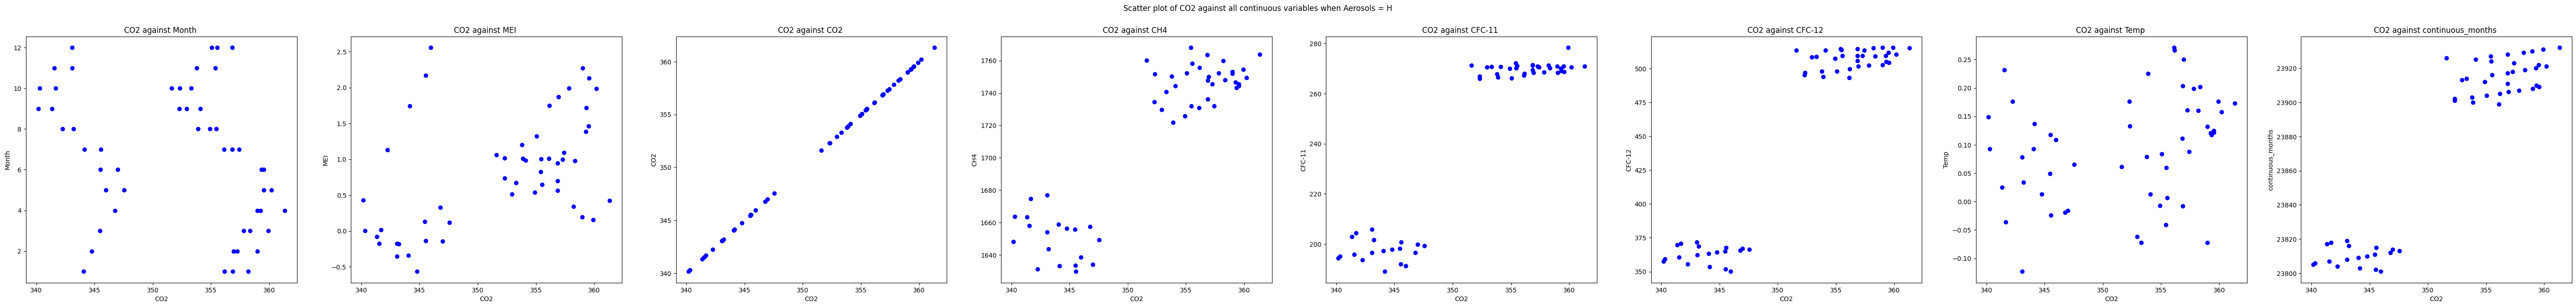

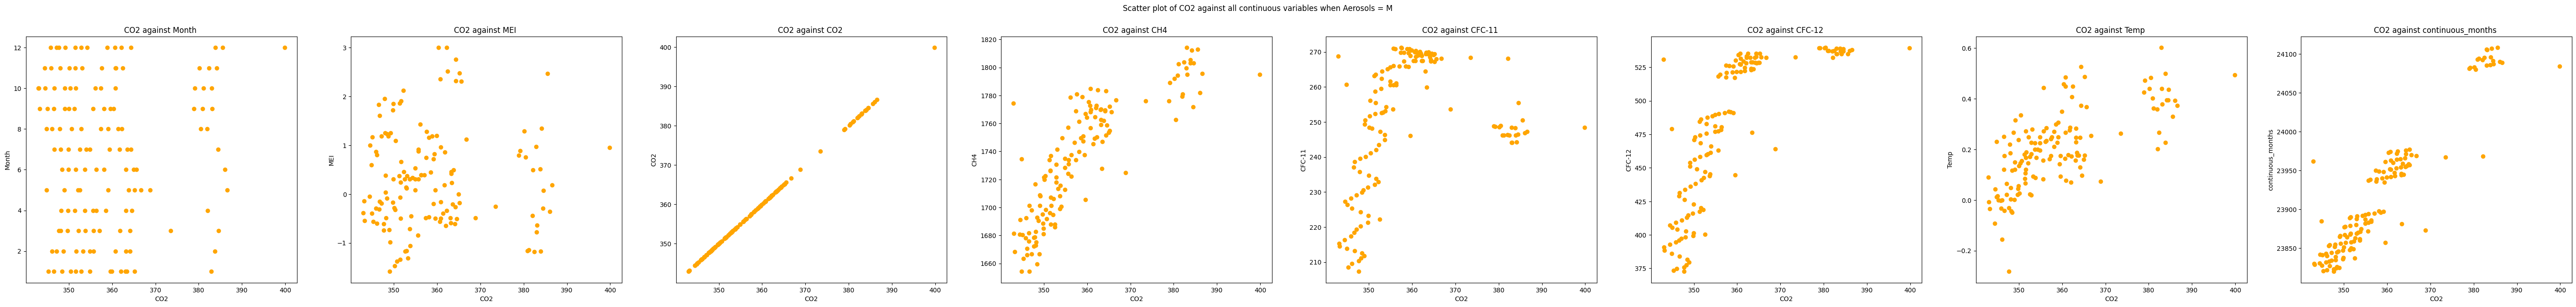

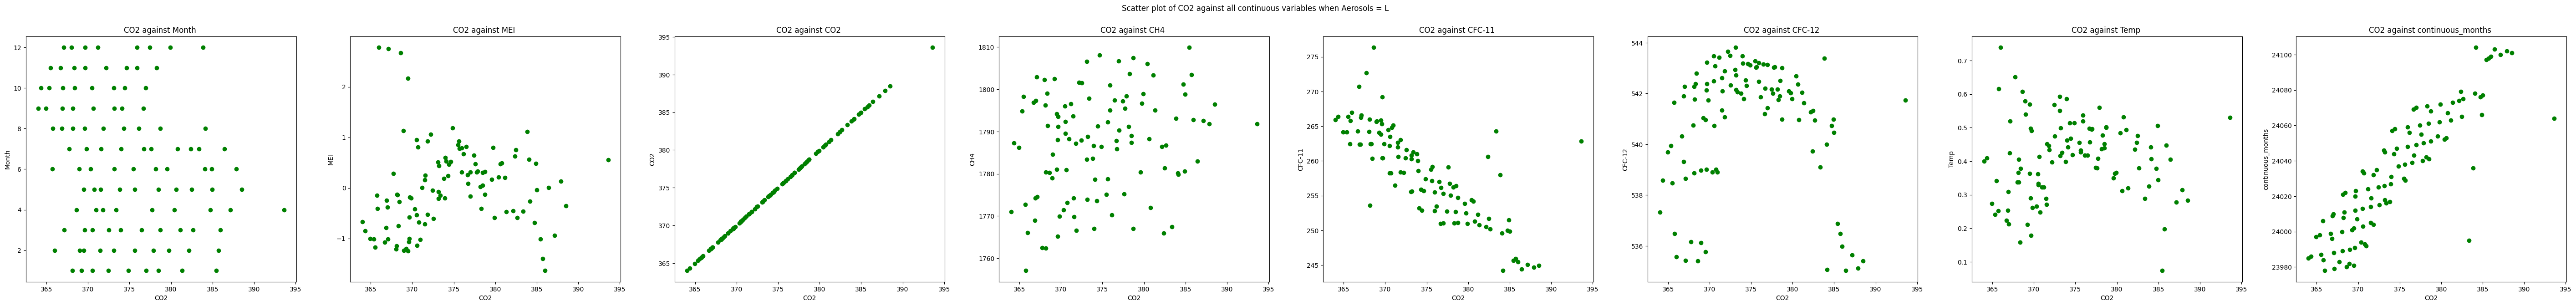

In [ ]:
# sample use case of plot_on_1_category
plot_on_1_category('Aerosols','H','CO2',dataset,color='blue')
plot_on_1_category('Aerosols','M','CO2',dataset,color='orange')
plot_on_1_category('Aerosols','L','CO2',dataset,color='green')

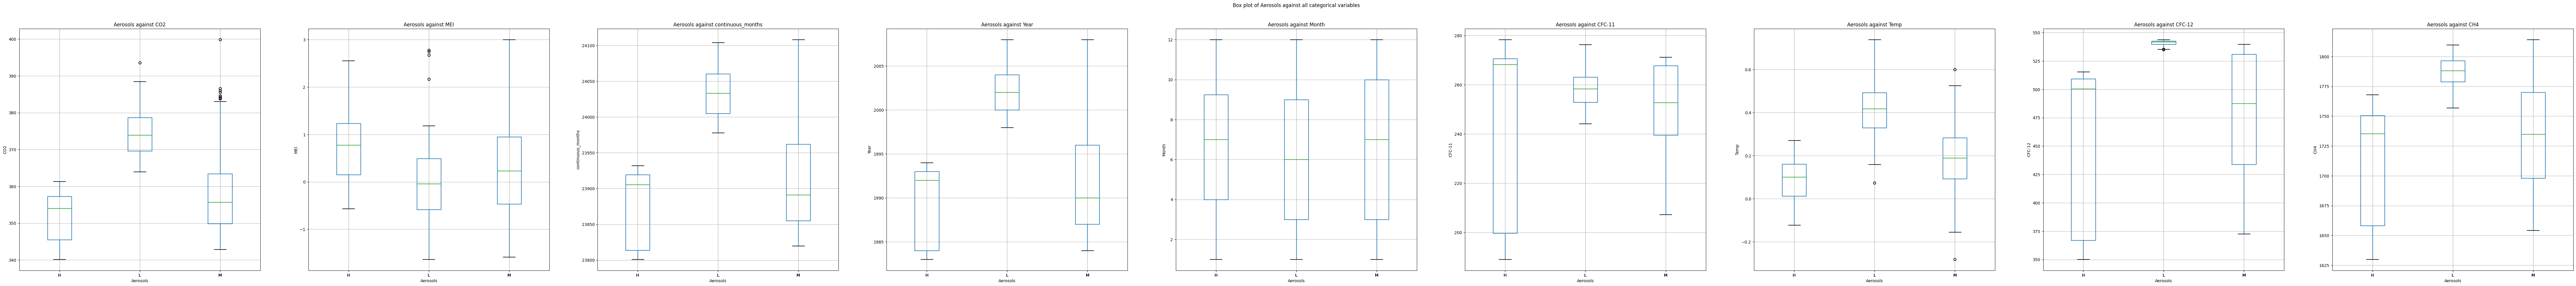

In [38]:
boxplot_across_category('Aerosols',dataset)

For Aerosols, the variables with distinctly separated values are:
- CO2  
(high and low have a distince separation while M takes on a composite range derived from these values )  
  
- CFC-11  
(all values are quite wildly varied)
  
- Temp  
(high and low have a distince separation while M takes on a composite range derived from these values )  
  
- CFC-12  
(high and low have a distince separation while M takes on a composite range derived from these values )  
  
- CH4  
(high and low have a distince separation while M takes on a composite range derived from these values )  
  

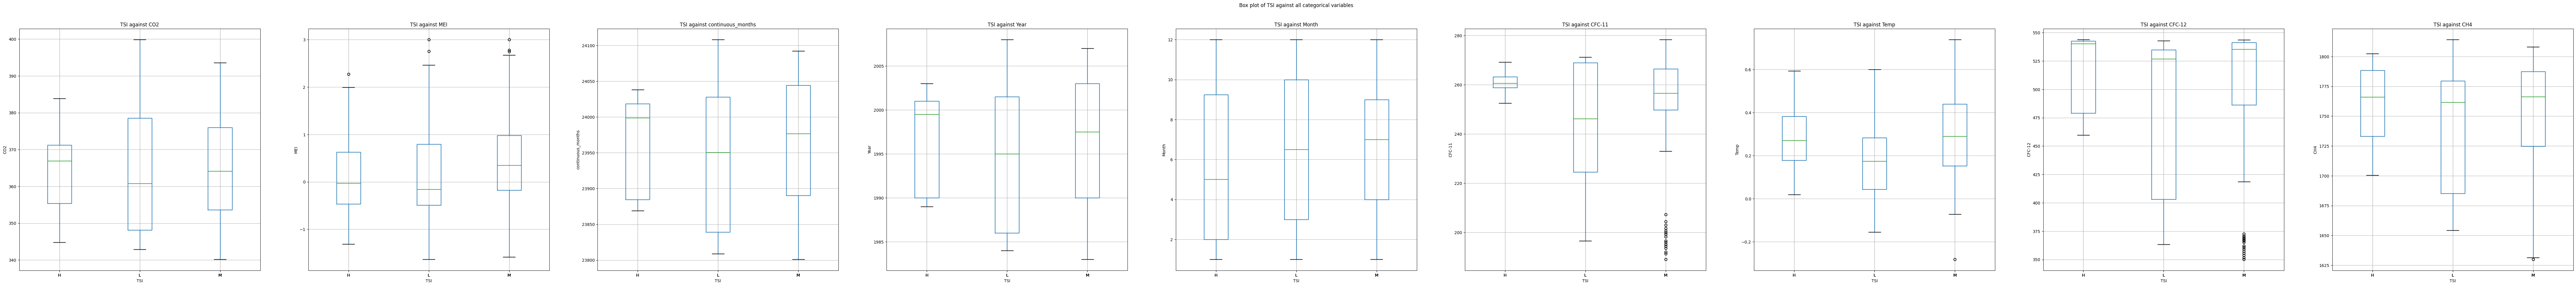

In [37]:
boxplot_across_category('TSI',dataset)

For TSI, the variables with distinctly separated values are:
- CFC-11
- CFC-12

  

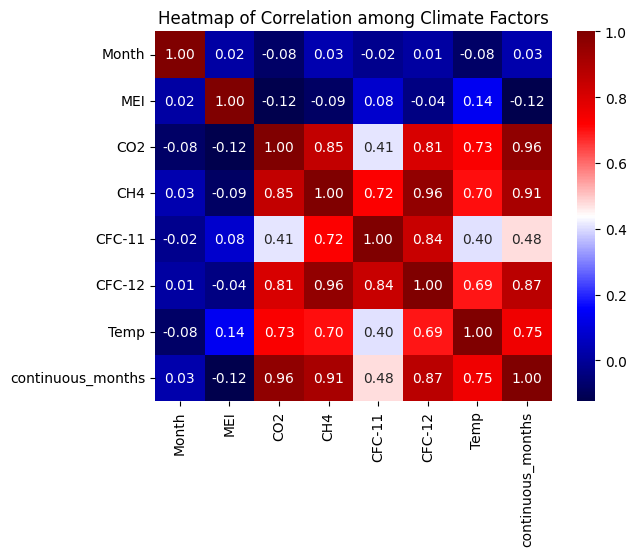

In [39]:
import seaborn as sns

continuous_variables = dataset.select_dtypes(include=['float64']).columns
datatset_correlations = dataset[continuous_variables].corr()

sns.heatmap(datatset_correlations, annot=True, fmt='.2f', cmap='seismic')
plt.title('Heatmap of Correlation among Climate Factors')
plt.show()

In [43]:
def corr_features(df, target, threshold):
    corr_features = []
    for feature in df.columns:
        if feature==target: continue
        x = df[feature]
        y = df[target]
        r2 = np.corrcoef(x,y)[0][1]
        if abs(r2)>threshold:
            corr_features.append(feature)
    return corr_features

features_selected = corr_features(dataset[continuous_variables], 'Temp', 0.5)
print(f"updated selected features: {features_selected}")

updated selected features: ['CO2', 'CH4', 'CFC-12', 'continuous_months']


we will get all correlations that are significant, and are more than 0.6:

In [49]:
retained = datatset_correlations[abs(datatset_correlations)>0.6]

col_index = len(continuous_variables)
significant_pairs = {}

for i in range(col_index):
    for j in range(col_index):
        
        pair = (continuous_variables[i], continuous_variables[j])
        value = float(retained.iloc[i, j])

        if value != 1 and abs(value) > 0.6 and pair[::-1] not in significant_pairs.keys():
            significant_pairs[pair] = value

for i in significant_pairs.items():
    print(i)

(('CO2', 'CH4'), 0.8528611525646903)
(('CO2', 'CFC-12'), 0.8050584436386704)
(('CO2', 'Temp'), 0.7322063270538742)
(('CO2', 'continuous_months'), 0.9606195085806064)
(('CH4', 'CFC-11'), 0.7236054770498506)
(('CH4', 'CFC-12'), 0.9586646324058945)
(('CH4', 'Temp'), 0.7022692958713286)
(('CH4', 'continuous_months'), 0.9115811875247718)
(('CFC-11', 'CFC-12'), 0.8381407359857861)
(('CFC-12', 'Temp'), 0.6938997429936312)
(('CFC-12', 'continuous_months'), 0.8718291574410246)
(('Temp', 'continuous_months'), 0.7511471762409055)


In [50]:
distinct_cols = []
for i in significant_pairs.keys():
    col1,col2 = i
    if col1 not in distinct_cols:
        distinct_cols.append(col1)
    if col2 not in distinct_cols:
        distinct_cols.append(col2)
print(distinct_cols)

['CO2', 'CH4', 'CFC-12', 'Temp', 'continuous_months', 'CFC-11']


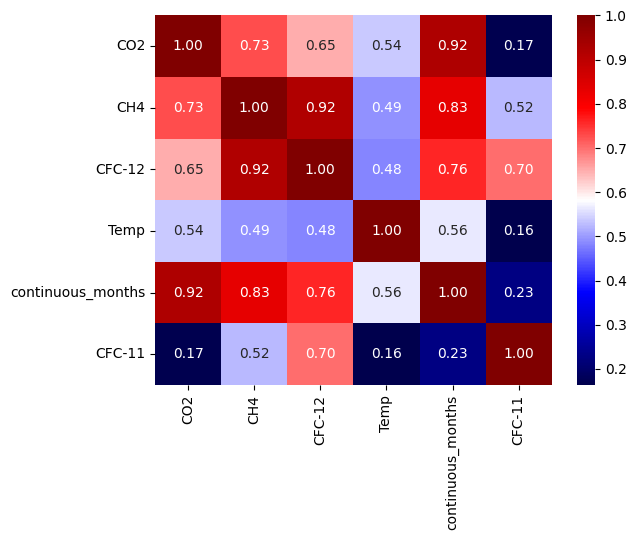

In [55]:
r2 = dataset[distinct_cols].corr()**2
sns.heatmap(r2, annot=True, fmt='.2f', cmap='seismic')

plt.show()

The r-squared values indicate that the following pairs of data likely have a linear trend:
- CFC-12 and CH4
- CO2 over time
- CFC-12 over time
- CH4 over time
- CH4 and CO2
- CFC-11 and CFC-12